# 02. 하이브리드 RAG 평가 — 데이터 적재와 평가셋 구축

## 왜 이 노트북이 필요한가

현재 AI 어시스턴트의 문서 검색(`retrieval_service.search_similar_chunks`)은 **밀집 벡터 단독**이다.
질문을 1024차원 벡터로 바꿔 `document_chunks.embedding`과 코사인 거리로 비교한다.

이 방식은 뜻이 통하면 단어가 달라도 찾지만, `WF-207` 같은 **짧고 고유한 토큰**은
벡터로 뭉개지면서 제목이 비슷한 다른 업무에 밀리기 쉽다.
실제로 `retrieval_service.py`에도 같은 문제를 인지한 주석과 우회 함수(`find_task_chunks_by_code`)가 있는데,
그 함수는 명령 처리 경로에서만 쓰이고 **질문 답변 경로에서는 쓰이지 않는다.**

그래서 어휘 검색(BM25)을 한 축 더 붙이는 **하이브리드**가 실제로 이득인지 숫자로 확인하려 한다.

## 이 평가가 DB를 건드리지 않는 이유

- 문서 임베딩은 이미 `document_chunks.embedding`에 있다 → 재임베딩 불필요
- 어휘 검색은 `content` 원문만 읽는다 → 새 컬럼·인덱스 불필요
- GIN 인덱스는 **속도**를 위한 것이지 **검색 결과**를 바꾸지 않는다 → 파이썬 메모리에서 계산해도 즉시

즉 **DB 쓰기 0건, 확장 설치 0건, 운영 코드 변경 0건**으로 판단 근거를 만든다.
아래 SQL은 전부 `SELECT`뿐이다.

## 이 노트북의 산출물

1. `output/hybrid_rag_eval/data/chunks_p1.json` — 평가 대상 청크 (임베딩 포함)
2. `output/hybrid_rag_eval/data/evalset.json` — 질문 30개 + 정답 라벨
3. `output/hybrid_rag_eval/figures/02_*.png` — 데이터 현황 그래프


## 1. 환경 설정

호스트의 `App/backend_fastapi/.venv` 커널로 실행한다. 저장소 루트 `.venv`에는 필요한 패키지가 없다.

In [1]:
from __future__ import annotations

import asyncio
import contextlib
import json
import re
import socket
import subprocess
import time
from collections import Counter
from pathlib import Path

import asyncpg
import matplotlib.pyplot as plt
import numpy as np

# 노트북이 docs/notebooks/ 아래로 옮겨져서 cwd가 더 이상 저장소 루트가 아니다.
# `App/`이 보이는 상위 디렉터리까지 거슬러 올라가 루트를 찾는다.
def _find_repo_root(marker: str = "App") -> Path:
    here = Path.cwd()
    for candidate in (here, *here.parents):
        if (candidate / marker).is_dir():
            return candidate
    raise RuntimeError(f"저장소 루트를 찾지 못했습니다 (현재: {here})")


ROOT = _find_repo_root()

OUT = ROOT / "output" / "hybrid_rag_eval"
FIG = OUT / "figures"
DATA = OUT / "data"
for d in (FIG, DATA):
    d.mkdir(parents=True, exist_ok=True)

# 그래프 한글 깨짐 방지 (macOS 기본 탑재 폰트)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

PROJECT_ID = 1  # 청크가 가장 많아 유일하게 평가 가능한 규모
print("설정 완료 / 대상 project_id =", PROJECT_ID)

설정 완료 / 대상 project_id = 1


## 2. DB 연결 — 운영(OCI) 서버

운영 DB는 `docker-compose.prod.yml`에서 `127.0.0.1:5432`에만 바인딩돼 외부로 노출되지 않는다.
따라서 **SSH 터널**을 열어 접속한다.

```
노트북 → localhost:15432 → [SSH 터널] → 서버 localhost:5432 → workflow-db
```

로컬 5432는 개발용 docker(`workflow-db`)가 이미 쓰고 있어 **15432**를 쓴다.

### 비밀번호를 파일에 두지 않는 이유

DB 비밀번호는 SSH로 서버 컨테이너의 환경변수를 그때그때 읽어 **메모리에만** 둔다.
저장소나 노트북 출력에 남기지 않는다 — `output/`은 산출물 폴더라 공유될 수 있다.
접근 권한은 이미 SSH 키로 통제되므로 별도 비밀 파일을 늘리지 않는 편이 안전하다.

`DB_TARGET`을 `"supabase"`로 바꾸면 2026-07-30 컷오버 시점 동결본으로 되돌릴 수 있다(대조용).

In [2]:
DB_TARGET = "oci"  # "oci" (운영 서버) | "supabase" (2026-07-30 동결본, 대조용)

OCI_SSH_HOST = "teamlead@161.33.132.66"
OCI_SSH_KEY = Path.home() / ".ssh" / "oci-key"
OCI_DB_CONTAINER = "workflow-db"
LOCAL_TUNNEL_PORT = 15432  # 5432는 로컬 개발용 docker가 점유


def _ssh(remote_cmd: str) -> str:
    r = subprocess.run(
        ["ssh", "-i", str(OCI_SSH_KEY), "-o", "BatchMode=yes", "-o", "ConnectTimeout=15",
         OCI_SSH_HOST, remote_cmd],
        capture_output=True, text=True, check=True,
    )
    return r.stdout.strip()


def _wait_port(port: int, timeout: float = 25.0) -> None:
    deadline = time.time() + timeout
    while time.time() < deadline:
        with contextlib.suppress(OSError):
            with socket.create_connection(("127.0.0.1", port), timeout=1):
                return
        time.sleep(0.3)
    raise TimeoutError(f"SSH 터널이 {timeout}초 안에 열리지 않았습니다 (port {port})")


@contextlib.contextmanager
def oci_tunnel():
    """SSH 터널을 열고, 블록을 벗어나면 반드시 닫는다(예외가 나도 프로세스가 남지 않게)."""
    proc = subprocess.Popen(
        ["ssh", "-i", str(OCI_SSH_KEY), "-o", "BatchMode=yes", "-o", "ExitOnForwardFailure=yes",
         "-N", "-L", f"{LOCAL_TUNNEL_PORT}:localhost:5432", OCI_SSH_HOST],
        stdout=subprocess.DEVNULL, stderr=subprocess.PIPE,
    )
    try:
        _wait_port(LOCAL_TUNNEL_PORT)
        yield
    finally:
        proc.terminate()
        with contextlib.suppress(subprocess.TimeoutExpired):
            proc.wait(timeout=10)


def resolve_dsn() -> tuple[dict, contextlib.AbstractContextManager]:
    """(asyncpg 연결 인자, 연결 유지에 필요한 컨텍스트) 를 돌려준다. 비밀번호는 출력하지 않는다."""
    if DB_TARGET == "oci":
        user = _ssh(f"docker exec {OCI_DB_CONTAINER} printenv POSTGRES_USER")
        db = _ssh(f"docker exec {OCI_DB_CONTAINER} printenv POSTGRES_DB")
        pw = _ssh(f"docker exec {OCI_DB_CONTAINER} printenv POSTGRES_PASSWORD")
        kwargs = dict(host="127.0.0.1", port=LOCAL_TUNNEL_PORT, user=user,
                      password=pw, database=db, ssl=False)
        return kwargs, oci_tunnel()

    if DB_TARGET == "supabase":
        from dotenv import dotenv_values
        url = dotenv_values(ROOT / "App" / ".env")["DATABASE_URL"].split("?")[0]
        return dict(dsn=url, ssl="require", statement_cache_size=0), contextlib.nullcontext()

    raise ValueError(f"알 수 없는 DB_TARGET: {DB_TARGET}")


print(f"DB_TARGET = {DB_TARGET}")

DB_TARGET = oci


## 3. 청크 적재

`document_chunks`에서 평가 대상 프로젝트의 청크를 임베딩까지 통째로 가져온다.
임베딩은 pgvector가 문자열(`'[0.1,0.2,...]'`)로 돌려주므로 파싱한다.

In [3]:
_SQL = """
SELECT id, source_type, source_id, assignee_id, content, embedding::text AS embedding
FROM document_chunks
WHERE project_id = $1 AND embedding IS NOT NULL
ORDER BY id
"""


async def load_chunks(project_id: int) -> list[dict]:
    kwargs, tunnel = resolve_dsn()
    with tunnel:
        conn = await asyncpg.connect(**kwargs)
        try:
            rows = await conn.fetch(_SQL, project_id)
            total = await conn.fetchval("SELECT count(*) FROM document_chunks")
        finally:
            await conn.close()
    print(f"DB 전체 청크 {total}건 / project_id={project_id} 적재 {len(rows)}건")
    return [{
        "id": r["id"],
        "source_type": r["source_type"],
        "source_id": r["source_id"],
        "assignee_id": r["assignee_id"],
        "content": r["content"],
        "embedding": json.loads(r["embedding"]),
    } for r in rows]


chunks = await load_chunks(PROJECT_ID)
EMB = np.array([c["embedding"] for c in chunks], dtype=np.float32)

print(f"임베딩 shape {EMB.shape}")
print("source_type:", Counter(c["source_type"] for c in chunks))

DB 전체 청크 444건 / project_id=1 적재 378건
임베딩 shape (378, 1024)
source_type: Counter({'task': 188, 'action_item': 169, 'meeting': 21})


## 4. 데이터 현황 파악

평가 결과를 해석하려면 **이 데이터가 어떤 데이터인지** 먼저 알아야 한다.
특히 중복과 테스트 데이터 비율은 지표를 직접 왜곡한다.

In [4]:
contents = [c["content"] for c in chunks]
dup = Counter(contents)
len_arr = np.array([len(c) for c in contents])
has_code = [bool(re.search(r"[A-Za-z]{2,}-\d+", c)) for c in contents]

print(f"총 청크        : {len(chunks)}")
print(f"고유 본문      : {len(dup)}  (중복 {len(chunks) - len(dup)}건)")
print(f"WF 코드 보유   : {sum(has_code)}건 ({sum(has_code)/len(chunks):.0%})")
print(f"본문 길이      : 중앙값 {np.median(len_arr):.0f}자 / 최대 {len_arr.max()}자")
print()
print("가장 많이 반복되는 본문:")
for text, n in dup.most_common(5):
    print(f"  x{n}  {text[:60]}")

총 청크        : 378
고유 본문      : 269  (중복 109건)
WF 코드 보유   : 95건 (25%)
본문 길이      : 중앙값 60자 / 최대 490자

가장 많이 반복되는 본문:
  x5  제안서 목차와 발표자료 역할을 나누 - 오늘은 제안서 목차와 발표자료 역할을 나누겠습니다 근거: 예린: 오늘
  x5  회의록 AI가 업무와 기여도 평가로 연결된다… - 핵심은 회의록 AI가 업무와 기여도 평가로 연결된다는 점이
  x5  첫 장에는 팀 회의 장면이나 대시보드 예시 … - 첫 장에는 팀 회의 장면이나 대시보드 예시 이미지를 넣는 
  x5  7월 14일까지 제안서 초안을 쓰 - 제가 7월 14일까지 제안서 초안을 쓰겠습니다 근거: 도윤: 제가 7월
  x5  기존 서비스 비교 표도 같이 넣 - 기존 서비스 비교 표도 같이 넣겠습니다 근거: 도윤: 기존 서비스 비교 


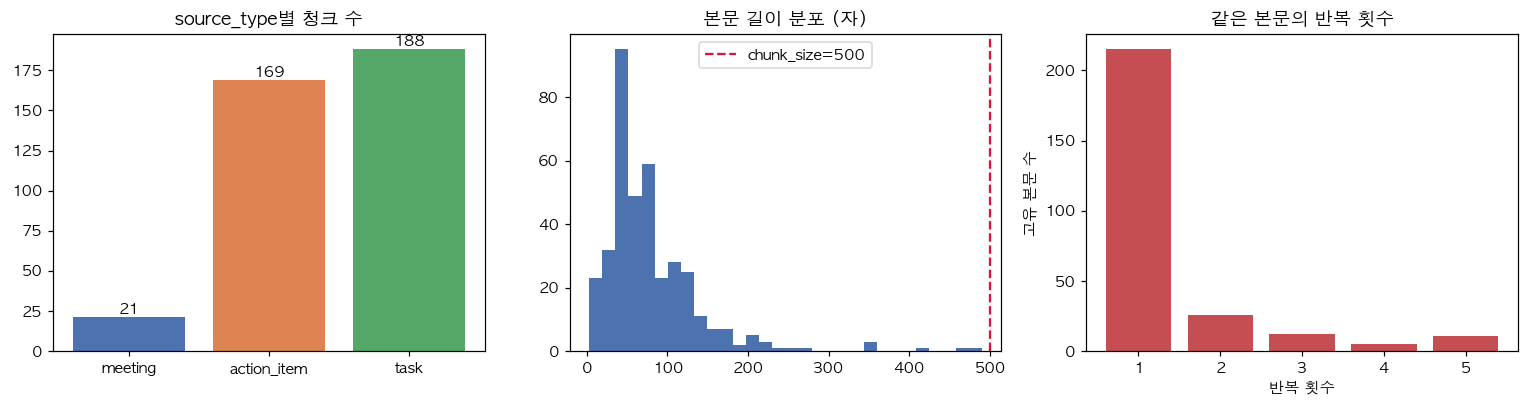

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

# (1) source_type 분포
st = Counter(c["source_type"] for c in chunks)
axes[0].bar(st.keys(), st.values(), color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("source_type별 청크 수")
for i, (k, v) in enumerate(st.items()):
    axes[0].text(i, v + 2, str(v), ha="center")

# (2) 본문 길이 분포 - 청크가 대부분 chunk_size(500) 미만이라 분할이 거의 없다
axes[1].hist(len_arr, bins=30, color="#4C72B0")
axes[1].axvline(500, color="crimson", ls="--", label="chunk_size=500")
axes[1].set_title("본문 길이 분포 (자)")
axes[1].legend()

# (3) 중복 배수 분포
axes[2].bar(*zip(*sorted(Counter(dup.values()).items())), color="#C44E52")
axes[2].set_title("같은 본문의 반복 횟수")
axes[2].set_xlabel("반복 횟수")
axes[2].set_ylabel("고유 본문 수")

plt.tight_layout()
plt.savefig(FIG / "02_corpus_overview.png", bbox_inches="tight")
plt.show()

### 데이터 품질 경고 (결과 해석 시 반드시 참고)

`project_id=1`은 **개발용 데모 프로젝트**다. 깨끗한 운영 데이터가 아니다.

| 관찰 | 평가에 미치는 영향 |
|---|---|
| task 설명이 대부분 `[Jira01 재검증 테스트 삽입] WF-xxx`로 덮여 있음 | WF 코드가 본문에 실재해 **식별자 가설 검증에는 오히려 유리**. 단 설명 본문의 의미 정보는 소실 |
| `07.29 테스트1`, `111`, `bye world...` 같은 순수 테스트 청크 다수 | 검색 노이즈. 두 방식 모두에 동일하게 작용하므로 비교 자체는 공정 |
| 같은 본문이 여러 번 중복 (task/action_item 양쪽 존재) | 정답을 청크 1건이 아니라 **집합**으로 라벨해야 함 → 아래에서 그렇게 처리 |
| `[Jira01 재검증 테스트 삽입]`이 다수 청크에 공통 | BM25는 IDF로 자동 감점하므로 무해. 단순 키워드 매칭이었다면 치명적이었을 지점 |

따라서 이 평가 결과는 **"이 프로젝트 데이터에서의 방향성"**으로 읽어야 하며, 정밀한 절대 수치가 아니다.

## 5. 평가셋 구축

### 정답 라벨을 만드는 방식

중복 본문 때문에 "정답 청크 id 하나"를 지정할 수 없다. 대신 **정규식 규칙**으로 정답 집합을 정의한다.
규칙에 걸리는 모든 청크가 정답이며, 검색 결과가 그중 **하나라도** 맞히면 성공으로 본다.
규칙은 사람이 읽고 검수할 수 있게 질문 옆에 그대로 남긴다.

데이터가 바뀌어도(운영 DB가 커져도) 규칙이 자동으로 재계산되므로 라벨을 다시 손댈 필요가 없다.

### 질문 3분류와 각각의 가설

| 분류 | 설계 원칙 | 가설 |
|---|---|---|
| `identifier` 고유 식별자형 | 질문에 `WF-xxx` 코드를 그대로 포함 | 어휘 우세 |
| `semantic` 의미·개념형 | **정답 본문과 표면 단어가 겹치지 않게** 일부러 다른 표현으로 작성 | 벡터 우세 |
| `mixed` 혼합형 | 고유명사(LightGBM, ERD, 사람 이름)를 포함하되 의미 이해도 필요 | 하이브리드 우세 |

`semantic` 질문을 "칸반 보드 업무 뭐야?"처럼 쓰면 정답 본문의 "칸반"과 글자가 겹쳐
어휘 검색에 부당하게 유리해진다. 그래서 "드래그해서 업무 상태를 옮기는 화면"처럼 **바꿔 말했다.**
이 설계가 평가의 공정성을 좌우한다.

In [6]:
# gold: 이 정규식 중 하나라도 본문에 걸리면 정답 청크로 본다.
EVALSET = [
    # ---------- A. 고유 식별자형 (질문에 코드 그대로 포함) ----------
    ("A01", "identifier", "WF-207이 무슨 업무야?",                      [r"WF-207(?!\d)"]),
    ("A02", "identifier", "WF-195 알려줘",                              [r"WF-195(?!\d)"]),
    ("A03", "identifier", "WF-233은 어떤 내용이야?",                    [r"WF-233(?!\d)"]),
    ("A04", "identifier", "WF-259가 뭐지?",                             [r"WF-259(?!\d)"]),
    ("A05", "identifier", "WF-264 업무 설명해줘",                       [r"WF-264(?!\d)"]),
    ("A06", "identifier", "WF-184가 뭐야?",                             [r"WF-184(?!\d)"]),
    ("A07", "identifier", "WF-238 관련 업무 알려줘",                    [r"WF-238(?!\d)"]),
    ("A08", "identifier", "WF-256이 뭔지 알려줘",                       [r"WF-256(?!\d)"]),
    ("A09", "identifier", "WF-220 상태 알려줘",                         [r"WF-220(?!\d)"]),
    ("A10", "identifier", "WF-243은 어떤 업무야",                       [r"WF-243(?!\d)"]),

    # ---------- B. 의미·개념형 (정답 본문과 표면 단어를 일부러 겹치지 않게 작성) ----------
    ("B01", "semantic", "드래그해서 업무 상태를 옮기는 화면 관련 업무 있어?",   [r"칸반"]),
    ("B02", "semantic", "문서를 검색 가능하게 색인하는 기능 알려줘",            [r"pgvector|RAG 인덱싱|임베딩 파이프라인"]),
    ("B03", "semantic", "외부 평가자가 팀원 성과를 확인하는 기능은?",           [r"기여도|심사자"]),
    ("B04", "semantic", "마감을 못 지킬 것 같은 업무를 미리 알려주는 기능 있어?", [r"지연 위험도"]),
    ("B05", "semantic", "누가 뭘 볼 수 있는지 통제하는 부분은 어떻게 돼 있어?",  [r"RBAC|권한"]),
    ("B06", "semantic", "회의 내용을 요약해서 할 일을 뽑아내는 기능",           [r"회의 분석|회의록 AI 분석|To-Do 후보"]),
    ("B07", "semantic", "오래 걸리는 작업을 기다리지 않고 처리하는 구조",       [r"비동기|폴링|Redis Queue"]),
    ("B08", "semantic", "슬라이드 만드는 건 누가 하기로 했어?",                [r"발표자료"]),
    ("B09", "semantic", "프로젝트 현황을 한눈에 보는 화면 관련 업무",          [r"대시보드 카드/차트|dashboard summary|대시보드 기본 집계"]),
    ("B10", "semantic", "특정 팀원한테 일이 몰리는지 보는 기능 있어?",         [r"업무 편중|업무량"]),

    # ---------- C. 혼합형 (고유명사 + 의미 이해 동시 필요) ----------
    ("C01", "mixed", "결제 API는 언제까지 하기로 했어?",                  [r"결제 API"]),
    ("C02", "mixed", "LightGBM 튜닝은 누가 맡았어?",                     [r"LightGBM"]),
    ("C03", "mixed", "KLUE-BERT 비교 결과는 언제 공유한대?",             [r"KLUE-BERT"]),
    ("C04", "mixed", "ERD 수정본 언제 공유해?",                          [r"ERD"]),
    ("C05", "mixed", "허영주가 맡은 일이 뭐야?",                         [r"허영주"]),
    ("C06", "mixed", "pgvector 스키마 만드는 업무가 뭐지?",              [r"pgvector"]),
    ("C07", "mixed", "중간발표 언제야?",                                 [r"중간발표"]),
    ("C08", "mixed", "박상준이 어떤 구조로 설계한다고 했어?",             [r"박상준: AI Assistant는 RAG"]),
    ("C09", "mixed", "OAuth 로그인 재발급 API는 누가 언제까지 한대?",     [r"OAuth 로그인과 JWT 재발급"]),
    ("C10", "mixed", "결측치는 어떻게 처리하기로 했어?",                  [r"결측치"]),
]

print(f"질문 {len(EVALSET)}개")
print(Counter(cat for _, cat, _, _ in EVALSET))

질문 30개
Counter({'identifier': 10, 'semantic': 10, 'mixed': 10})


### 라벨 검증

정답이 0건인 질문이 있으면 그 질문은 **어떤 검색기로도 맞힐 수 없어** 지표를 조용히 깎는다.
반대로 정답이 지나치게 많으면 아무거나 뽑아도 맞아서 변별력이 없다.

두 번째를 판정할 때 **정답 개수가 아니라 "우연히 맞을 확률"로 재는 게 맞다.**
같은 20건이라도 전체가 300건일 때와 3000건일 때 의미가 다르기 때문이다.
308건 중 정답 1건이면 상위 5개를 아무렇게나 뽑아도 맞을 확률이 1.6%지만,
정답 18건이면 26%다. 후자는 검색기가 아무 일도 안 해도 26점을 받는다는 뜻이라
점수가 실력인지 운인지 구분되지 않는다.

기준은 **우연 적중률 20%**로 잡는다.

In [7]:
CHANCE_LIMIT = 0.20  # 우연 적중률이 이 값을 넘으면 "느슨"으로 표시


def gold_ids(patterns: list[str]) -> list[int]:
    rx = [re.compile(p) for p in patterns]
    return [c["id"] for c in chunks if any(r.search(c["content"]) for r in rx)]


evalset = []
problems = []
for qid, cat, question, patterns in EVALSET:
    ids = gold_ids(patterns)
    # 상위 5개를 무작위로 뽑았을 때 정답이 하나라도 걸릴 확률(우연 바닥값)
    miss = 1.0
    for i in range(5):
        miss *= (len(chunks) - len(ids) - i) / (len(chunks) - i)
    evalset.append({
        "id": qid, "category": cat, "question": question,
        "gold_patterns": patterns, "gold_ids": ids, "gold_count": len(ids),
        "chance_hit5": round(1 - miss, 3),
    })
    if len(ids) == 0:
        problems.append(f"{qid} 정답 0건 - 라벨 규칙 오류")
    elif 1 - miss > CHANCE_LIMIT:
        problems.append(f"{qid} 우연 적중률 {1-miss:.0%} (>{CHANCE_LIMIT:.0%}) - 느슨함, 정답 {len(ids)}건")

print(f"{'문항':<5} {'정답':>4} {'우연':>6}  질문")
print("-" * 78)
for q in evalset:
    print(f"{q['id']:<5} {q['gold_count']:>4} {q['chance_hit5']:>6.1%}  {q['question']}")

print()
if problems:
    print("!! 검토 필요:")
    for p in problems:
        print("  -", p)
else:
    print("모든 질문의 정답 라벨 정상")

LOOSE_QIDS = sorted({p.split()[0] for p in problems})
print("\n느슨 문항:", LOOSE_QIDS or "없음")

문항      정답     우연  질문
------------------------------------------------------------------------------
A01      1   1.3%  WF-207이 무슨 업무야?
A02      1   1.3%  WF-195 알려줘
A03      1   1.3%  WF-233은 어떤 내용이야?
A04      1   1.3%  WF-259가 뭐지?
A05      1   1.3%  WF-264 업무 설명해줘
A06      1   1.3%  WF-184가 뭐야?
A07      1   1.3%  WF-238 관련 업무 알려줘
A08      1   1.3%  WF-256이 뭔지 알려줘
A09      1   1.3%  WF-220 상태 알려줘
A10      1   1.3%  WF-243은 어떤 업무야
B01      3   3.9%  드래그해서 업무 상태를 옮기는 화면 관련 업무 있어?
B02      4   5.2%  문서를 검색 가능하게 색인하는 기능 알려줘
B03     21  25.0%  외부 평가자가 팀원 성과를 확인하는 기능은?
B04      6   7.7%  마감을 못 지킬 것 같은 업무를 미리 알려주는 기능 있어?
B05     13  16.1%  누가 뭘 볼 수 있는지 통제하는 부분은 어떻게 돼 있어?
B06     12  15.0%  회의 내용을 요약해서 할 일을 뽑아내는 기능
B07      6   7.7%  오래 걸리는 작업을 기다리지 않고 처리하는 구조
B08     25  29.1%  슬라이드 만드는 건 누가 하기로 했어?
B09      4   5.2%  프로젝트 현황을 한눈에 보는 화면 관련 업무
B10     14  17.3%  특정 팀원한테 일이 몰리는지 보는 기능 있어?
C01      1   1.3%  결제 API는 언제까지 하기로 했어?
C02      3   3.9%  LightGBM 튜닝은 누가 맡았어?
C03      2   2.6%  KLUE-BE

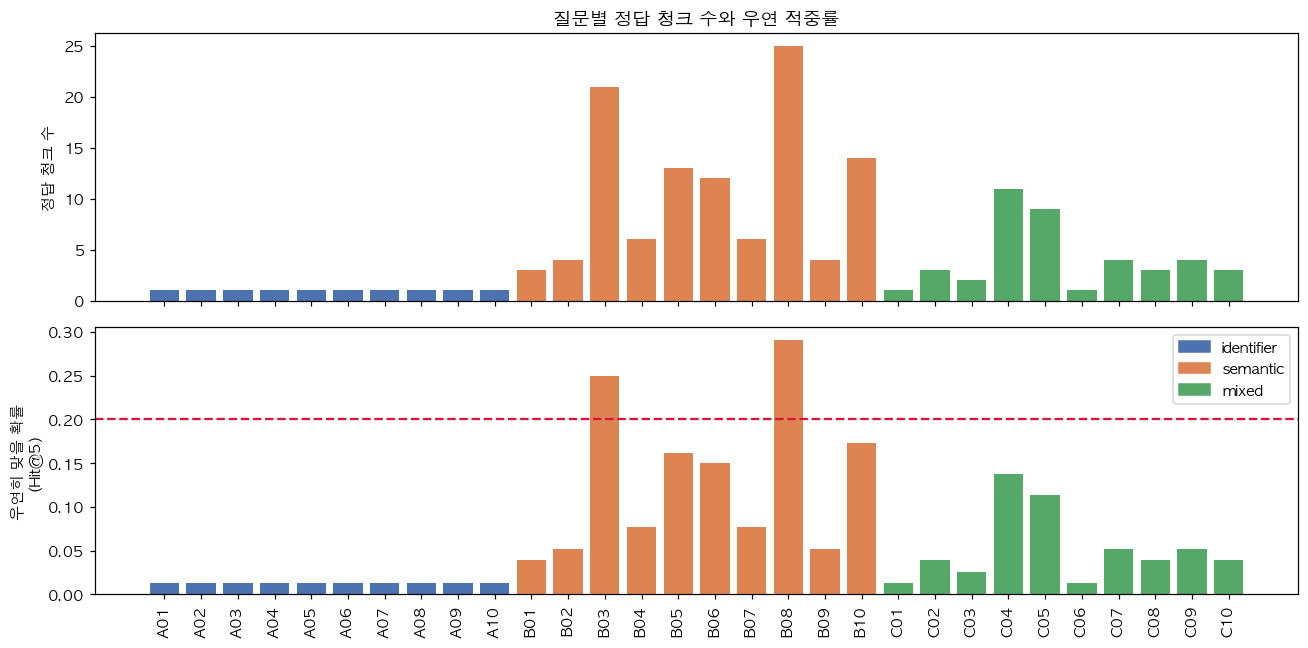

정답 수 중앙값: 3


In [8]:
gold_counts = [q["gold_count"] for q in evalset]
colors = {"identifier": "#4C72B0", "semantic": "#DD8452", "mixed": "#55A868"}

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].bar([q["id"] for q in evalset], gold_counts,
            color=[colors[q["category"]] for q in evalset])
axes[0].set_ylabel("정답 청크 수")
axes[0].set_title("질문별 정답 청크 수와 우연 적중률")

axes[1].bar([q["id"] for q in evalset], [q["chance_hit5"] for q in evalset],
            color=[colors[q["category"]] for q in evalset])
axes[1].axhline(CHANCE_LIMIT, color="crimson", ls="--", label=f"느슨 기준 {CHANCE_LIMIT:.0%}")
axes[1].legend(loc="upper left")
axes[1].set_ylabel("우연히 맞을 확률\n(Hit@5)")
axes[1].tick_params(axis="x", rotation=90)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
axes[1].legend(handles, colors.keys())

plt.tight_layout()
plt.savefig(FIG / "02_gold_distribution.png", bbox_inches="tight")
plt.show()

print("정답 수 중앙값:", int(np.median(gold_counts)))

## 6. 저장

다음 노트북(`02-1`)이 DB에 다시 붙지 않도록 청크와 평가셋을 파일로 남긴다.

In [9]:
chunks_path = DATA / "chunks_p1.json"
evalset_path = DATA / "evalset.json"
meta_path = DATA / "source_meta.json"

chunks_path.write_text(json.dumps(chunks, ensure_ascii=False), encoding="utf-8")
evalset_path.write_text(json.dumps(evalset, ensure_ascii=False, indent=2), encoding="utf-8")
meta_path.write_text(json.dumps({
    "db_target": DB_TARGET, "project_id": PROJECT_ID,
    "n_chunks": len(chunks), "n_unique_contents": len(dup),
    "chance_limit": CHANCE_LIMIT, "loose_qids": LOOSE_QIDS,
}, ensure_ascii=False, indent=2), encoding="utf-8")

print("저장 완료")
for p in (chunks_path, evalset_path, meta_path):
    print(f"  {p.relative_to(ROOT)}  ({p.stat().st_size/1e3:.1f} KB)")
print(f"  {FIG.relative_to(ROOT)}/02_*.png")

저장 완료
  output/hybrid_rag_eval/data/chunks_p1.json  (4906.2 KB)
  output/hybrid_rag_eval/data/evalset.json  (9.0 KB)
  output/hybrid_rag_eval/data/source_meta.json  (0.2 KB)
  output/hybrid_rag_eval/figures/02_*.png


## 정리

- 평가 대상: **운영(OCI) 서버**의 `project_id=1` 청크 (임베딩 포함). SSH 터널로 읽기 전용 접속
- 평가셋: 질문 30개를 `identifier` / `semantic` / `mixed` 3분류로 구성, 정답은 정규식 규칙으로 집합 라벨
- `semantic` 질문은 정답 본문과 표면 단어가 겹치지 않게 의도적으로 바꿔 써서 어휘 검색에 유리한 편향을 제거
- 각 문항의 **우연 적중률**을 함께 계산해, 변별력 없는 문항을 자동으로 표시

**다음 노트북 `02-1`**: 검색기 3종(벡터 단독 / BM25 단독 / RRF 하이브리드)을 구현하고
Recall@k · MRR · nDCG로 비교한다.